# DQN Snake Model Analysis
This notebook analyzes the performance and decision-making of the trained DQN agent for Snake.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import deque, Counter
import os

# Import your SnakeGame, DQN, DQNAgent classes here
from deep_ql.dql_snake import SnakeGame, DQN, DQNAgent, GRID_SIZE, MODEL_PATH

# Set up environment and agent
env = SnakeGame(grid_size=GRID_SIZE)
agent = DQNAgent()
agent.model.load_state_dict(torch.load(MODEL_PATH))
agent.model.eval()

DQN(
  (fc1): Linear(in_features=16, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

## Run Evaluation Episodes and Collect Data

In [2]:
num_episodes = 200
scores = []
rewards = []
actions_all = []
q_values_all = []

for ep in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0
    actions = []
    q_vals = []
    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = agent.model(state_tensor).squeeze().numpy()
        action = np.argmax(q_values)
        actions.append(action)
        q_vals.append(q_values)
        next_state, reward, done = env.step(action)
        total_reward += reward
        state = next_state
    scores.append(env.score)
    rewards.append(total_reward)
    actions_all.extend(actions)
    q_values_all.extend(q_vals)

## Analytical Graphs

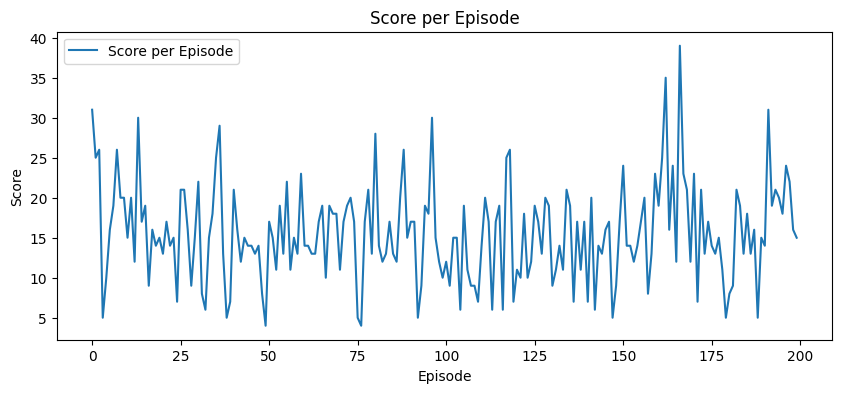

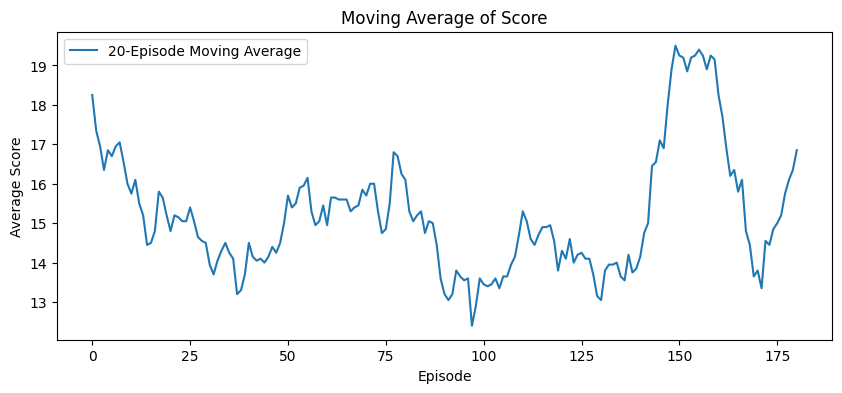

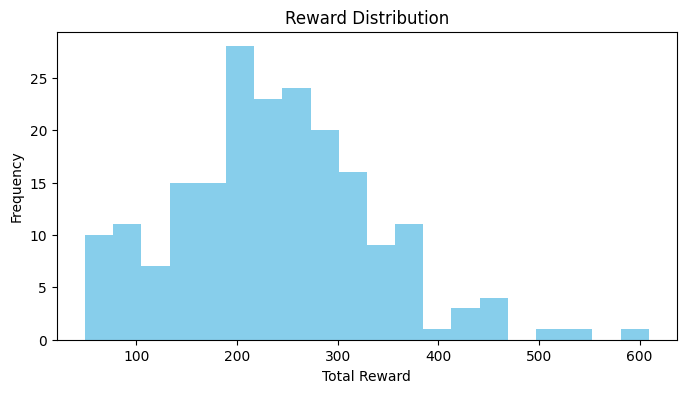

In [3]:
# Score per episode
plt.figure(figsize=(10,4))
plt.plot(scores, label='Score per Episode')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Score per Episode')
plt.legend()
plt.show()

# Moving average
window = 20
moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10,4))
plt.plot(moving_avg, label=f'{window}-Episode Moving Average')
plt.xlabel('Episode')
plt.ylabel('Average Score')
plt.title('Moving Average of Score')
plt.legend()
plt.show()

# Reward distribution
plt.figure(figsize=(8,4))
plt.hist(rewards, bins=20, color='skyblue')
plt.xlabel('Total Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution')
plt.show()

## Decision-Making Graphs

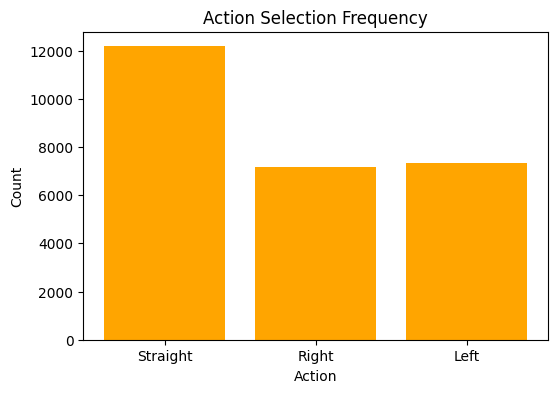

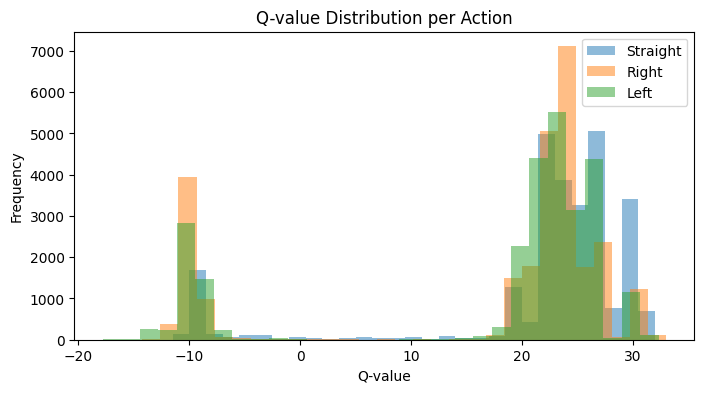

In [4]:
# Action selection frequency
action_counts = Counter(actions_all)
actions = ['Straight', 'Right', 'Left']
counts = [action_counts.get(i,0) for i in range(3)]
plt.figure(figsize=(6,4))
plt.bar(actions, counts, color='orange')
plt.xlabel('Action')
plt.ylabel('Count')
plt.title('Action Selection Frequency')
plt.show()

# Q-value distributions
q_values_all = np.array(q_values_all)
plt.figure(figsize=(8,4))
for i, action in enumerate(actions):
    plt.hist(q_values_all[:,i], bins=30, alpha=0.5, label=action)
plt.xlabel('Q-value')
plt.ylabel('Frequency')
plt.title('Q-value Distribution per Action')
plt.legend()
plt.show()